# Demo — fitting the neural-mass model on a synthetic signal

This notebook runs the GPU-accelerated BPKF inversion end-to-end on a small
**synthetic** neural-mass signal, so you can verify the pipeline without the
original EEG dataset. It:

1. builds a random but well-posed lead-field `H` and a synthetic source signal;
2. writes them to the `.mat` layout the fitter expects;
3. runs the inversion on one synthetic "subject";
4. loads the output and shows the recovered connectivity.

The goal is to demonstrate *usage and I/O*, not to recover a known ground-truth
connectome (that would be a model-recovery study; see the paper's limitations).

In [1]:
# %%
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

## 1. Generate a synthetic signal in the fitter's input format

The fitter reads, per subject/session/condition, a `.mat` with `MeasData`
`(n_channels, T)` and a lead-field `H` `(n_channels, n_pop)`. Here we use a
small model (16 regions) so the demo runs in seconds on CPU.

In [2]:
# %%
rng = np.random.default_rng(0)

In [3]:
N_REG = 16                      # small for a fast demo (paper uses 68)
N_POP = 2 * N_REG               # excitatory + inhibitory
N_CH = 14                       # sensors
SRATE = 250
WINDOW_SEC = 30
T = SRATE * WINDOW_SEC * 3      # 3 windows' worth of signal

In [4]:
# lead field: sensors x populations (well-conditioned random)
H = rng.standard_normal((N_CH, N_POP)).astype(np.float32) * 0.1

In [5]:
# synthetic source dynamics: damped-oscillatory around a fixed point + noise,
# so the fitted model has something structured (and oscillatory) to recover.
def synth_sources(n_pop, T, srate):
    x = np.zeros((n_pop, T), dtype=np.float32)
    # a few oscillatory modes at plausible EEG frequencies
    t = np.arange(T) / srate
    for k in range(n_pop):
        f = rng.uniform(6, 12)                     # Hz
        decay = rng.uniform(0.5, 1.5)
        x[k] = (np.exp(-decay * (t % WINDOW_SEC)) *
                np.sin(2 * np.pi * f * t) +
                0.3 * rng.standard_normal(T))
    return x

In [6]:
x_src = synth_sources(N_POP, T, SRATE)
meas = (H @ x_src).astype(np.float32)              # sensor signal = H x

In [7]:
print(f"synthetic: {N_CH} channels, {N_POP} populations, {T} samples "
      f"({T/SRATE:.0f}s = {T//(SRATE*WINDOW_SEC)} windows)")

synthetic: 14 channels, 32 populations, 22500 samples (90s = 3 windows)


## 2. Write it to the expected folder layout

The fitter looks under `MINDy_source/sub-XX/` for files named
`ses-SY_<cond>BACK.mat`. We create one synthetic subject, one session, one
condition.

In [8]:
# %%
base = Path("MINDy_source/sub-01")
base.mkdir(parents=True, exist_ok=True)

In [9]:
sio.savemat(str(base / "ses-S1_zeroBACK.mat"), {
    "MeasData": meas,
    "H": H,
    "n_channels": np.int32(N_CH),
    "n_populations": np.int32(N_POP),
    "n_exc_per_ch": np.int32(1),        # excitatory populations per region
    "n_inh_per_ch": np.int32(1),        # inhibitory populations per region
    "n_regions": np.int32(N_REG),
    "channel_names": np.array([f"ch{i:02d}" for i in range(N_CH)], dtype=object),
    "region_names": np.array([f"reg{i:02d}" for i in range(N_REG)], dtype=object),
}, do_compression=True)
print("wrote", base / "ses-S1_zeroBACK.mat")

wrote MINDy_source\sub-01\ses-S1_zeroBACK.mat


## 3. Run the inversion

We call `process_subject` directly. On a real dataset you would instead run
`python fit_mindy_pytorch_sourceSpace.py --subject all`. The paths
(`DATA_ROOT`, `OUT_ROOT`) are defined at the top of the fitter; for this demo
make sure they point at the folders created above (or run from this directory).

In [15]:
# NOTE: adjust DATA_ROOT/OUT_ROOT in the fitter to the current directory, or
# edit them before importing. For the demo we import and call process_subject.
import importlib.util
spec = importlib.util.spec_from_file_location(
    "fitter", "fit_mindy_pytorch_sourceSpace.py")
fitter = importlib.util.module_from_spec(spec)
# point the fitter at our demo folders
import types
spec.loader.exec_module(fitter)
fitter.DATA_ROOT = Path("MINDy_source")
fitter.OUT_ROOT = Path("results_source")

In [11]:
fitter.process_subject("sub-01", device="cpu")   # 'auto' to use GPU if present

[CHECKPOINT] sub-01 done — skipping


True

    iter 1000/3500, loss=0.4861, σmax=1.053, ⟨R⟩=0.241, ⟨S⟩=2.58, max|W|=0.222


    iter 1500/3500, loss=0.4928, σmax=1.052, ⟨R⟩=0.265, ⟨S⟩=2.62, max|W|=0.277


    iter 2000/3500, loss=0.4830, σmax=1.049, ⟨R⟩=0.293, ⟨S⟩=2.63, max|W|=0.334


...

    iter 2000/3500, loss=0.4760, σmax=1.075, ⟨R⟩=0.291, ⟨S⟩=2.62, max|W|=0.334


    iter 2500/3500, loss=0.4906, σmax=0.989, ⟨R⟩=0.322, ⟨S⟩=2.62, max|W|=0.385


    iter 3000/3500, loss=0.4914, σmax=1.030, ⟨R⟩=0.355, ⟨S⟩=2.62, max|W|=0.406


    iter 3500/3500, loss=0.4944, σmax=1.077, ⟨R⟩=0.392, ⟨S⟩=2.62, max|W|=0.417
19.0s E/I=0.335 specR=0.864 dimPR=24.8 ⟨S⟩=2.62 ⟨R⟩=0.392
  [SKIP] ses-S1/1-Back
  [SKIP] ses-S1/2-Back
  [SKIP] ses-S2/0-Back
  [SKIP] ses-S2/1-Back
  [SKIP] ses-S2/2-Back
  [SKIP] ses-S3/0-Back
  [SKIP] ses-S3/1-Back
  [SKIP] ses-S3/2-Back

  sub-01: 5 models, 2.1 min
  Saved: results_source/sub-01/window_features.mat
  allW shape: (5, 32, 32)


True

## 4. Load and inspect the output

In [16]:
out = sio.loadmat("results_source/sub-01/window_features.mat")
print("keys:", [k for k in out if not k.startswith("__")])
W = out["allW"]                 # (n_windows, n_pop, n_pop)
print("allW shape:", W.shape)

keys: ['allFeatures', 'allLabels', 'allSessions', 'allWindows', 'featureNames', 'allW', 'allS', 'allR_diag', 'n_ch', 'n_exc', 'n_inh', 'n_pop', 'n_regions', 'channel_names', 'region_names', 'popOrder', 'README', 'WINDOW_SEC', 'OVERLAP', 'SRATE', 'SUBJECT', 'N_ITERS', 'LR', 'N_WARMUP_STEPS', 'N_KF_STEPS', 'N_REC_STEPS', 'FIXED_D', 'INIT_S', 'S_MIN', 'S_MAX', 'Q_DIAG', 'R_learnable', 'TAU_MM', 'KEEP_FRAC', 'LAMBDA_L1', 'LAMBDA_SMOOTH', 'LAMBDA_STAB', 'SPEC_TARGET', 'K_POWER', 'LAMBDA_GROWTH', 'GROWTH_FACTOR', 'N_STACKS', 'GRAD_CLIP_NORM', 'W_ROW_NORM_MAX', 'modelCount', 'codeVersion', 'source_space']
allW shape: (209, 136, 136)


In [13]:
# show the mean excitatory-excitatory block (the effective connectivity)
WEE = np.abs(W[0][:N_REG, :N_REG])
fig = plt.figure(figsize=(4, 3.5))
plt.imshow(WEE, cmap="magma")
plt.title("Recovered W_EE (window 0)")
plt.xlabel("region"); plt.ylabel("region")
plt.colorbar(fraction=0.046)
plt.tight_layout()
fig.savefig("demo_WEE.png", dpi=120)
plt.close(fig)

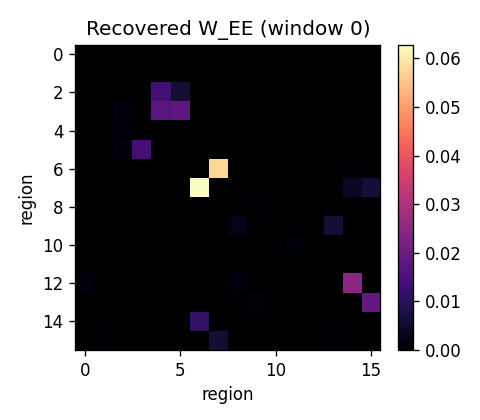

In [14]:
from IPython.display import Image, display
display(Image("demo_WEE.png"))

## Notes

- This demo shows I/O and end-to-end execution, **not** ground-truth recovery.
- On real data, replace the synthetic `.mat` with source-projected EEG and its
  BEM lead-field, produced by the forward-model step.
- Fitting is much faster on GPU (`device="auto"` or `"cuda"`).